In [1]:
import numpy as np
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        # Back substitution
    M = np.zeros(n)
    M[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        M[i] = (d[i] - c[i] * M[i+1]) / b[i]
    return M

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1])) # Right-hand side vector
    return A, B, C, D

In [3]:
# Example data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)

M = thomas_algorithm(A, B, C, D)
M = np.insert(M, 0, 0)
M = np.append(M, 0)
print(M)

Subdiagonal (A): [1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1.]
Right-hand side (D): [-12.  12. -12.  12.]
[ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


In [4]:
def evaluate_spline(M,x,y, xeval):
    n = len(x)
    h = np.diff(x)
    S = np.zeros(n)
    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)
    for i in range(0, n-1):
        a[i] = y[i]
        b[i] = ((y[i+1]-y[i])/h[i])-(h[i]/6)*(M[i+1]+2*M[i])
        c[i] = M[i]/2
        d[i] = (M[i+1]-M[i])/(6*h[i])
        
        
    print(M)
    print(a)
    print(b)
    print(c)
    print(d)
    
    start = xeval.astype(int) # which part of the spline to use while evlauating
    # print(start)
    
    yeval = a[start] + b[start]*(xeval-x[start]) + c[start]*(xeval-x[start])**2 + d[start]*(xeval-x[start])**3
    return yeval
    

In [7]:
xeval = np.linspace(0,5,1000)
yeval = evaluate_spline(M,x,y,xeval)


[ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]
[0. 1. 0. 1. 0. 0.]
[ 1.72727273 -0.45454545  0.09090909  0.09090909 -0.45454545  0.        ]
[ 0.         -2.18181818  2.72727273 -2.72727273  2.18181818  0.        ]
[-0.72727273  1.63636364 -1.81818182  1.63636364 -0.72727273  0.        ]


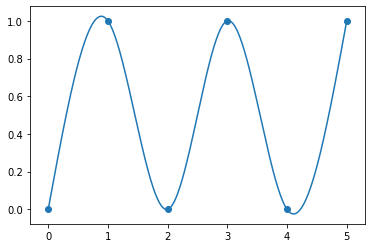

In [8]:
import matplotlib.pyplot as plt
yeval = yeval[0:len(yeval)-1]
xeval = xeval[0:len(xeval)-1]
plt.plot(xeval,yeval)
plt.scatter(x,y)

plt.show()